In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm



## DQN — Deep Q-Network (Mnih et al., Nature 2015)

The agent learns an action-value function `Q(s, a; θ)` that obeys the Bellman optimality equation. Two design tricks make it work:

1. **Replay memory** `D` — break the temporal correlation of consecutive transitions by sampling random minibatches from a buffer of past experience.
2. **Target network** `Q(s, a; θ⁻)` — a slowly-updating copy of `Q` used to compute the regression target, which keeps the target stable while `θ` moves.

**TD target and loss (paper Eq. 2):**

$$
y = r + \gamma \max_{a'} Q(s', a'; \theta^-),\qquad
L(\theta) = \big(y - Q(s, a; \theta)\big)^2
$$

**Symbols used here:**

| Symbol           | Meaning                                                                | Variable             |
|------------------|------------------------------------------------------------------------|----------------------|
| `Q(·;θ)`         | online action-value network                                            | `Q_network`          |
| `Q(·;θ⁻)`        | target network                                                         | `Q_target`           |
| `D`              | replay buffer                                                          | `replay_buffer`      |
| `γ`              | discount                                                                | `gamma`              |
| `ε(t)`           | exploration probability (decays from `eps_start` to `eps_end`)         | `eps`                |
| `τ`              | Polyak coefficient when soft-updating the target net                   | `tau`                |

This implementation supports both **soft** target updates (`target_update_freq=0`, uses `τ`) and **hard** updates (`target_update_freq=k`, copies weights every `k` learning steps).

---

### 1. Replay Memory (`D`)

A FIFO buffer of `(s, a, r, s', done)` tuples. Random sampling is what gives DQN its i.i.d.-like training signal.

In [2]:
class ReplayMemory(object):

    def __init__(self, memory_size, batch_size):
        self.batch_size = batch_size
        self.memory_size = memory_size
        self.memory = []

    def insert(self, state, action, reward, next_state, end):
        memory_batch = (state, action, reward, next_state, end)
        self.memory.append(memory_batch)
        if len(self.memory) > self.memory_size:
            self.memory.pop(0)

    def sample(self):
        batch = random.sample(self.memory, self.batch_size)
        states = [i[0] for i in batch]
        actions = [i[1] for i in batch]
        rewards = [i[2] for i in batch]
        next_states = [i[3] for i in batch]
        ends = [i[4] for i in batch]
        return states, actions, rewards, next_states, ends

    def __len__(self):
        return len(self.memory)


### 2. Q-Network

A plain MLP `Q : ℝ^{dim_S} → ℝ^{dim_A}`. The network outputs **one Q-value per discrete action**, so picking the greedy action is just an `argmax` over its output (no second forward pass per action).

We instantiate it twice — once as the online net `Q(·;θ)`, once as the target net `Q(·;θ⁻)` — both share the same architecture.

In [3]:
class QNetwork(nn.Module):

    def __init__(self, arch):
        super().__init__()
        self.arch = arch
        if len(self.arch) < 2:
            raise ValueError("Layer size cannot be smaller than 2")

        layers = []
        for in_features, out_features in zip(self.arch[:-1], self.arch[1:]):
            layers.append(nn.Linear(in_features, out_features))
            if out_features != self.arch[-1]:
                layers.append(nn.ReLU())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


### 3. RunDQN — Algorithm 1 of Mnih et al.

Methods map 1:1 to the paper's training loop:

| Method            | Paper line                                                       |
|-------------------|------------------------------------------------------------------|
| `choose_action`   | "select action with ε-greedy" — ε decays exponentially toward `eps_end` |
| `train`           | "sample minibatch from D; compute target y; SGD on `(y − Q(s,a;θ))²`" |
| `hard_update` / `soft_update` | "every C steps, set θ⁻ ← θ" (paper) or its Polyak smoothed variant |
| `learn`           | the outer episode loop                                           |

**Key knobs:**
- `step_skipping` — only do an SGD update every `k` env steps (lets the buffer fill faster than gradients are taken).
- `start_step` — number of env steps to fill the buffer with a random policy before any learning starts.
- `target_update_freq=0` switches to soft updates with coefficient `τ`; any positive int does a hard copy every that many learning steps.
- `clip` — gradient *value* clip (paper used reward clipping for Atari; here we keep gradient clipping which is gentler).

In [4]:
class RunDQN(object):
    def __init__(self,
            env,
            lr=5e-4,
            batch_size=256,
            gamma=0.99,
            arch=None,
            clip=1,
            eps=[0.9, 2500, 0.1],   # [eps_start, decay_steps, eps_end] — exponential decay
            step_skipping=4,
            tau=0.005,
            target_update_freq=0,   # 0 → soft updates with τ; >0 → hard copy every k learn steps
            start_step=100,
            memory_size=10000):

        self.step = 0
        self.env = env
        self.lr = lr
        self.batch_size = batch_size
        self.gamma = gamma
        self.clip = clip
        self.eps = eps
        self.step_skipping = step_skipping
        self.tau = tau
        self.target_update_freq = target_update_freq
        self.memory_size = memory_size
        self.start_step = start_step
        self.dim_A = env.action_space.n
        self.dim_S = env.observation_space.shape[0]
        self.arch = arch if arch is not None else [self.dim_S, 128, 128, self.dim_A]

        if self.arch[0] != self.dim_S or self.arch[-1] != self.dim_A:
            raise ValueError("arch must start with the state size and end with the action size")
        if self.target_update_freq < 0:
            raise ValueError("target_update_freq must be non-negative")
        if self.target_update_freq == 0 and (self.tau is None or self.tau <= 0):
            raise ValueError("tau must be positive when target_update_freq is 0")

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.replay_buffer = ReplayMemory(self.memory_size, self.batch_size)

        self.Q_network = QNetwork(self.arch).to(self.device)
        self.Q_target = QNetwork(self.arch).to(self.device)
        self.Q_target.load_state_dict(self.Q_network.state_dict())

        self.optimizer = optim.Adam(self.Q_network.parameters(), lr=self.lr)

    def _reset_env(self):
        reset_result = self.env.reset()
        return reset_result[0] if isinstance(reset_result, tuple) else reset_result

    def _step_env(self, action):
        step_result = self.env.step(action)
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, _ = step_result
        return next_state, reward, done

    def choose_action(self, state):
        # ε(t) = eps_end + (eps_start − eps_end) · exp(−t / decay_steps)
        self.step_eps = self.eps[-1] + (self.eps[0] - self.eps[-1]) * np.exp(-self.step / self.eps[1])
        self.step += 1

        if random.random() < self.step_eps:
            return random.randrange(self.dim_A)

        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            action_values = self.Q_network(state_tensor)
            return action_values.argmax(dim=1).item()

    def hard_update(self):
        self.Q_target.load_state_dict(self.Q_network.state_dict())

    def soft_update(self):
        # θ⁻ ← τ θ + (1 − τ) θ⁻
        for target_param, online_param in zip(self.Q_target.parameters(), self.Q_network.parameters()):
            target_param.data.copy_(self.tau * online_param.data + (1 - self.tau) * target_param.data)

    def train(self):
        if len(self.replay_buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, ends = self.replay_buffer.sample()
        states = torch.tensor(np.array(states), dtype=torch.float32, device=self.device)
        actions = torch.tensor(actions, dtype=torch.long, device=self.device).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=self.device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=self.device)
        ends = torch.tensor(ends, dtype=torch.float32, device=self.device).unsqueeze(1)

        # Q(s, a; θ) — value the online net assigns to the action we actually took
        q_values = self.Q_network(states).gather(1, actions)

        # y = r + γ max_a' Q(s', a'; θ⁻) · (1 − done)
        with torch.no_grad():
            next_q_values = self.Q_target(next_states).max(dim=1, keepdim=True)[0]
            targets = rewards + self.gamma * next_q_values * (1 - ends)

        criterion = nn.MSELoss()
        loss = criterion(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.Q_network.parameters(), self.clip)
        self.optimizer.step()

        return loss.item()

    def learn(self, num_episodes, max_steps=500):
        self.env_step = 0
        self.learn_step = 0
        episode_rewards = []
        losses = []

        for _ in tqdm(range(num_episodes)):
            state = self._reset_env()
            total_r = 0.0

            for _ in range(max_steps):
                action = self.choose_action(state)
                next_state, reward, done = self._step_env(action)

                self.replay_buffer.insert(state, action, reward, next_state, done)
                state = next_state
                total_r += reward
                self.env_step += 1

                if self.env_step > self.start_step and self.env_step % self.step_skipping == 0:
                    loss = self.train()
                    if loss is not None:
                        losses.append(loss)
                        self.learn_step += 1

                        if self.target_update_freq == 0:
                            self.soft_update()
                        elif self.learn_step % self.target_update_freq == 0:
                            self.hard_update()

                if done:
                    break

            episode_rewards.append(total_r)

        return episode_rewards, losses

### 4. Train on CartPole-v1 (single seed)

A single training run. Useful for a quick sanity check before doing a full multi-seed evaluation.

100%|██████████| 400/400 [00:36<00:00, 11.09it/s]


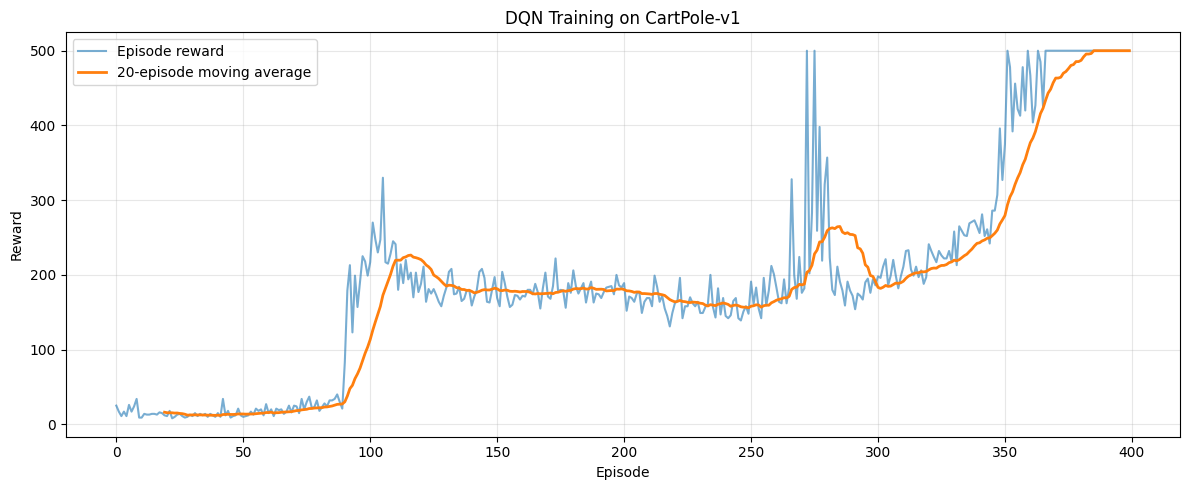

In [5]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")

agent = RunDQN(
    env=env,
    lr=5e-4,
    batch_size=256,
    gamma=0.99,
    arch=[env.observation_space.shape[0], 128, 128, env.action_space.n],
    clip=1.0,
    eps=[0.95, 600, 0.05],
    step_skipping=2,
    tau=0.01,
    target_update_freq=0,
    start_step=100,
    memory_size=100000,
)

episode_rewards, losses = agent.learn(num_episodes=400)
env.close()

window = min(20, len(episode_rewards))
moving_average = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(12, 5))
plt.plot(episode_rewards, label="Episode reward", alpha=0.6)
plt.plot(
    range(window - 1, len(episode_rewards)),
    moving_average,
    label=f"{window}-episode moving average",
    linewidth=2,
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Training on CartPole-v1")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 5. Multi-seed evaluation

Three seeds, identical hyperparameters. Each run's reward curve is smoothed with a 20-episode moving average; we then plot the across-seed **mean ± 1 std** with `fill_between`. This is the same protocol as the PPO notebook so the two are directly comparable.

100%|██████████| 400/400 [00:46<00:00,  8.62it/s]


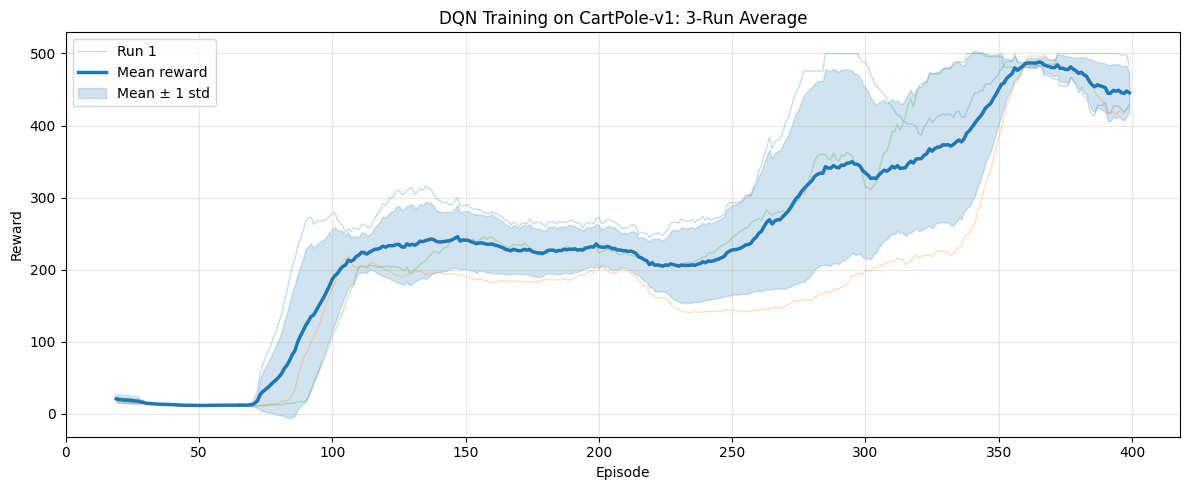

Final 20-episode averages per run: [429.4, 423.15, 483.6]
Final averaged curve value: 445.38


In [6]:
import random
import gymnasium as gym
import matplotlib.pyplot as plt

num_runs = 3
seeds = [0, 16, 25]
num_episodes = 400
window = 20

reward_runs = []

for seed in seeds[:num_runs]:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)

    agent = RunDQN(
        env=env,
        lr=5e-4,
        batch_size=256,
        gamma=0.99,
        arch=[env.observation_space.shape[0], 128, 128, env.action_space.n],
        clip=1.0,
        eps=[0.95, 600, 0.05],
        step_skipping=2,
        tau=0.01,
        target_update_freq=0,
        start_step=100,
        memory_size=100000,
    )

    episode_rewards, _ = agent.learn(num_episodes=num_episodes)
    reward_runs.append(episode_rewards)
    env.close()

reward_runs = np.array(reward_runs)

def moving_average(values, window):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

smoothed_runs = np.array([moving_average(run, window) for run in reward_runs])
episodes = np.arange(window - 1, num_episodes)

mean_rewards = smoothed_runs.mean(axis=0)
std_rewards = smoothed_runs.std(axis=0)

plt.figure(figsize=(12, 5))
for idx, run in enumerate(smoothed_runs):
    plt.plot(episodes, run, alpha=0.25, linewidth=1, label=f"Run {idx + 1}" if idx == 0 else None)

plt.plot(episodes, mean_rewards, color="tab:blue", linewidth=2.5, label="Mean reward")
plt.fill_between(
    episodes,
    mean_rewards - std_rewards,
    mean_rewards + std_rewards,
    color="tab:blue",
    alpha=0.2,
    label="Mean ± 1 std",
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Training on CartPole-v1: 3-Run Average")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Final 20-episode averages per run:", [round(run[-20:].mean(), 2) for run in reward_runs])
print("Final averaged curve value:", round(mean_rewards[-1], 2))
